# start here

In [1]:
import numpy as np
import flopy 
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import json
import os

c:\Users\lima0055\anaconda3\envs\gmdsitut\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
model_name='tracer_sim' 
mf6_model_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK/3d_injection_modeling_PMW-3"
k_files_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK"
model_ws = os.path.join(k_files_path, 'prt_simulation')
os.makedirs(model_ws, exist_ok=True)

In [3]:
gwf_name = f"{model_name}-gwf"
prt_name = f"{model_name}-prt"

In [4]:
'''mf6_files = [f for f in os.listdir(mf6_model_path) if f.endswith('.nam')]

if not mf6_files: 
    raise FileNotFoundError(f'No MODFLOW 6 name file found in {mf6_model_path}')
        
#load mf6 sim
old = flopy.mf6.MFSimulation.load( 
    #sim_name = self.model_name, 
    exe_name = 'mf6', 
    sim_ws = mf6_model_path
)

mf6_model = old.get_model() 
grid = mf6_model.modelgrid '''

"mf6_files = [f for f in os.listdir(mf6_model_path) if f.endswith('.nam')]\n\nif not mf6_files: \n    raise FileNotFoundError(f'No MODFLOW 6 name file found in {mf6_model_path}')\n\n#load mf6 sim\nold = flopy.mf6.MFSimulation.load( \n    #sim_name = self.model_name, \n    exe_name = 'mf6', \n    sim_ws = mf6_model_path\n)\n\nmf6_model = old.get_model() \ngrid = mf6_model.modelgrid "

In [4]:
nper = 2  # Number of periods
nlay = 3
nrow_inner = 350
ncol_inner = 350
dx = 1.0 #1 meter finer cell size
dy = dx
dx_outer = [1.5 ** i for i in range(1, 20)]
dy_outer = dx_outer
delr = dx_outer[::-1] + ncol_inner * [dx] + dx_outer
delc = dy_outer[::-1] + nrow_inner * [dy] + dy_outer
delr = np.array(delr)
delc = np.array(delc)
nrow = delc.shape[0]
ncol = delr.shape[0]
top = 0. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [-14. * 0.3048, -16. * 0.3048, -30. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]
    
#porosity = 0.0016  # aquifer porosity (unitless) USED IN AGU RESULTS
porosity = 0.0004457368 #porosity based on the caluclation of field peak concentration using AGU geom mean K 
'''
top = 30. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [16. * 0.3048, 14. * 0.3048, 0. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]'''

'\ntop = 30. * 0.3048 #ft to meters\ntop = top * np.ones((nrow, ncol), dtype=float)\nbotm = -30. * 0.3048 #ft to meters (30ft thick)\nbotm = botm * np.ones((nlay, nrow, ncol), dtype=float)\n\nbotm_dis = [16. * 0.3048, 14. * 0.3048, 0. * 0.3048 ] #defining bottom of each layer (3 layers)\nfor layer in range(nlay): \n    botm[layer] = botm_dis[layer]'

In [5]:
settings = {
            'steady_state_days': 14, #how many days to run to achieve heads steady state given the boundary conditions
            'tracking_days': 60, #tracking days for tracer test
            'n_particles': 5000, 
            'output_frequency_days': 0.02, #output every 0.5 hours
            'release_duration_days': 0.002, #~3 minutes for pulse
        }

In [6]:
sim = flopy.mf6.MFSimulation(
    sim_name=model_name, exe_name="mf6", version="mf6", sim_ws=model_ws
)

In [7]:
tdis = flopy.mf6.modflow.mftdis.ModflowTdis(
            sim,
            pname="tdis",
            time_units="DAYS",
            nper=nper,
            perioddata=[
                (settings['steady_state_days'],  # PERLEN: 14 days
                14,      # NSTP: 14 timesteps (once a day)
                1.0),      # TSMULT: 1.0 
                (settings['tracking_days'],  # PERLEN: 30 days
                #1440,      # NSTP: 1440 timesteps (0.02083333 day = 0.5 hours each)
                20,
                1.0) 
            ],
        )

In [8]:
model_nam_file = f"{gwf_name}.nam"
gwf = flopy.mf6.ModflowGwf(
    sim, modelname=gwf_name, model_nam_file=model_nam_file, save_flows=True
)

In [9]:
ims = flopy.mf6.modflow.mfims.ModflowIms(
    sim,
    pname="ims",
    complexity="SIMPLE",
    
    outer_dvclose=1e-4,
    inner_dvclose=1e-6,
    rcloserecord=[1e-6, "strict"],
    linear_acceleration="CG",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=0.97,
)
sim.register_solution_package(ims, [gwf.name])

In [10]:
model_grid = flopy.discretization.StructuredGrid(
    delr=delr, 
    delc=delc, 
    top=top, 
    botm=botm
)

In [11]:
MLAC_center = [480788.5,4980060.5]
grid_length_x = delr.sum()
grid_length_y = delc.sum()
xoff = MLAC_center[0] - 0.5 * grid_length_x
yoff = MLAC_center[1] - 0.5 * grid_length_y
#model_grid.set_coord_info(xoff=xoff, yoff=yoff)

In [12]:
dis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    gwf,
    pname="dis",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    length_units="METER",
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    xorigin=xoff, #x-position of the lower-left corner of the model grid
    yorigin=yoff
)

In [14]:
#gwf.modelgrid.set_coord_info(xoff=xoff, yoff=yoff)

In [15]:
#ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname="ic", strt=100.0)

In [13]:
hk1 = np.loadtxt(os.path.join(k_files_path, "k_layer1.txt"))
hk2 = np.loadtxt(os.path.join(k_files_path, "k_layer2.txt"))
hk3 = np.loadtxt(os.path.join(k_files_path, "k_layer3.txt"))

k_dict = [{
    "filename": "../k_layer1_prt.txt", 
    "factor": 1.0, 
    "data": hk1, 
    "iprn": 1, #to print info on list file for debugging
    "format": "(388F10.6)"
}, 
{
    "filename": "../k_layer2_prt.txt", 
    "factor": 1.0, 
    "data": hk2, 
    "iprn": 1, 
    "format": "(388F10.6)"
},
{
    "filename": "../k_layer3_prt.txt", 
    "factor": 1.0, 
    "data": hk3, 
    "iprn": 1, 
    "format": "(388F10.6)"
},]

npf = flopy.mf6.ModflowGwfnpf(
    gwf, 
    k=k_dict,
    save_flows=True,
    save_specific_discharge=True, 
    save_saturation=True
)

In [14]:
ss1 = np.loadtxt(os.path.join(k_files_path, "ss_layer1.txt"))
ss2 = np.loadtxt(os.path.join(k_files_path, "ss_layer2.txt"))
ss3 = np.loadtxt(os.path.join(k_files_path, "ss_layer3.txt"))

ss_dict = [{
    "filename": "../ss_layer1_prt.txt", 
    "factor": 1.0, 
    "data": ss1, 
    "iprn": 1, #to print info on list file for debugging
    "format": "(388F10.6)"
}, 
{
    "filename": "../ss_layer2_prt.txt", 
    "factor": 1.0, 
    "data": ss2, 
    "iprn": 1, 
    "format": "(388F10.6)"
},
{
    "filename": "../ss_layer3_prt.txt", 
    "factor": 1.0, 
    "data": ss3, 
    "iprn": 1, 
    "format": "(388F10.6)"
},]


sto = flopy.mf6.modflow.mfgwfsto.ModflowGwfsto(
    gwf,
    save_flows=True,
    iconvert=1,
    ss=ss_dict,
    #steady_state={0: True},
    #transient={1: True},
)

In [15]:
headfile = f"{gwf_name}.hds"
budgetfile = f"{gwf_name}.cbb"
oc = flopy.mf6.modflow.mfgwfoc.ModflowGwfoc(
    gwf,
    pname="oc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    head_filerecord=[headfile],
    budget_filerecord=[budgetfile],
)

In [16]:
prt = flopy.mf6.ModflowPrt(
    sim, modelname=prt_name, model_nam_file=f"{prt_name}.nam"
)

In [17]:
mip = flopy.mf6.ModflowPrtmip(prt, pname="mip", porosity=porosity) #izone=izone deleted/comment out

In [18]:
prtdis = flopy.mf6.modflow.mfgwfdis.ModflowGwfdis(
    prt,
    pname="dis",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    length_units="METER",
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    xorigin=xoff, #x-position of the lower-left corner of the model grid
    yorigin=yoff
)

In [19]:
x = prt.modelgrid.xcellcenters[128, 176]
y = prt.modelgrid.ycellcenters[128, 176]

In [20]:
x_hz_start = prt.modelgrid.xcellcenters[245, 185]
y_hz_start = prt.modelgrid.ycellcenters[245, 185]

x_hz_end = prt.modelgrid.xcellcenters[138, 301]
y_hz_end = prt.modelgrid.ycellcenters[138, 301]

In [21]:
release_data = []

wells = {
            'PMW-3': {
                'easting': 480770.0, 
                'northing': 4980127.0, 
                #'easting': x, 
                #'northing': y,
                'layer': 1, #second layer BPP (zero-indexed)
                'total_mass_mg': 2024.0
            }, 
            'horizontal_well': {
                'start_easting': 480895.0,
                'start_northing': 4980117.0,
                'end_easting': 480783.0,
                'end_northing': 4980010.0,
                #'start_easting': x_hz_start,
                #'start_northing': y_hz_start,
                #'end_easting': x_hz_end,
                #'end_northing': y_hz_end, 
                'layer': 1, #BPP layer
                'diameter_m': 0.1 #REVIEW THAT
            }
        }

inj_row, inj_col = sim.get_model().modelgrid.intersect(
            wells['PMW-3']['easting'], 
            wells['PMW-3']['northing'], 
            #wells['PMW-3']['layer']
        )

inj_layer = 1

for i in range(settings['n_particles']):

    release_data.append(
        (i, #particle index
        #self.grid.get_node([(inj_layer,inj_row,inj_col)])[0], #node
        inj_layer, inj_row, inj_col, #release index (?), lyr, row, col
        wells['PMW-3']['easting'], wells['PMW-3']['northing'], 
        0.5 #center of cell
        #particle_mass, 
        #self.settings['release_duration_days']
        )
    )

'''mp7_face_data = flopy.modpath.FaceDataType(
    verticaldivisions1=5, verticaldivisions2=5, verticaldivisions3=5, verticaldivisions4=5,
    horizontaldivisions1=5, horizontaldivisions2=5, horizontaldivisions3=5, horizontaldivisions4=5,
    rowdivisions5=0, rowdivisions6=0, columndivisions5=0, columndivisions6=0,
)'''


celldata = flopy.modpath.CellDataType(
    drape=0,
    rowcelldivisions=100,
    columncelldivisions=100,
    layercelldivisions=1,
)

mp7_particle_data = flopy.modpath.LRCParticleData(
    subdivisiondata=[celldata],
    lrcregions=[[[inj_layer, inj_row, inj_col, inj_layer, inj_row, inj_col]]]
)
release_pts = list(mp7_particle_data.to_prp(prt.modelgrid, localz=False))


In [22]:
len(release_pts)

10000

In [23]:
np.set_printoptions(suppress=True)

In [27]:
#release_pts = [(x1, x2, x3, x4, x5, x6, -4.572) for x1, x2, x3, x4, x5, x6, _ in release_pts]

In [24]:
#prt release
prp = flopy.mf6.ModflowPrtprp(
    prt,
    pname="prp1",
    filename="{}_1.prp".format(prt_name),
    nreleasepts=len(release_pts),
    packagedata=release_pts,
    perioddata={1: ["FIRST"]}, #particles will be released at the first timestep of the second stress period
    #nreleasetimes=len(release_times),
    #releasetimes=[(t,) for t in release_times],
    # local z coordinates specified, compute global release
    # coord from cell top if saturated or water table if not
    local_z=False,
    exit_solve_tolerance=1e-5,
    #extend_tracking=True,
)

In [25]:
budgetfile_prt = f"{prt_name}.cbb"
trackfile_prt = f"{prt_name}.trk"
trackhdrfile_prt = f"{prt_name}.trk.hdr"
trackcsvfile_prt = f"{prt_name}.trk.csv"

track_times = np.linspace(0, settings['tracking_days'], 500).tolist()
'''oc = flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=[budgetfile_prt],
    trackcsv_filerecord=[trackcsvfile_prt],
    track_release=True,
    #track_terminate=True,
    #track_usertime=True,
    #ntracktimes=len(track_times),
    #tracktimes=[(t,) for t in track_times],
    track_exit=True,
    saverecord=[("BUDGET", "ALL")],
)'''
oc = flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=[budgetfile_prt],
    trackcsv_filerecord=[trackcsvfile_prt],
    track_release=True,      # record at particle release
    track_exit=True,         # record every time a particle exits a cell (crosses boundary)
    track_terminate=True,    # record at particle termination
    track_usertime=False,    # no fixed time interval tracking
    saverecord=[("BUDGET", "ALL")],
)

In [26]:
exg = flopy.mf6.ModflowGwfprt(
    sim,
    exgtype="GWF6-PRT6",
    exgmnamea=gwf_name,
    exgmnameb=prt_name,
    filename=f"{gwf_name}.gwfprt",
)

In [27]:
ems = flopy.mf6.ModflowEms(
    sim,
    pname="ems",
    filename=f"{prt_name}.ems",
)
sim.register_solution_package(ems, [prt.name])

In [28]:
# Get horizontal well midpoint
hw = wells['horizontal_well']
hw_mid_x = (hw['start_easting'] + hw['end_easting']) / 2
hw_mid_y = (hw['start_northing'] + hw['end_northing']) / 2
hw_row, hw_col = sim.get_model().modelgrid.intersect(
    hw_mid_x, hw_mid_y
)
hw_layer = 1

# Set heads
base_head = 100.0 #m
head_difference = 1.5 #m
hw_head = base_head - head_difference

# Create CHD cells
chd_cells = []

# 1. Injection well (higher head)
chd_cells.append([inj_layer, inj_row, inj_col, base_head])

# 2. Horizontal well cells (lower head)
n_hw_points = 20
for i in range(n_hw_points):
    s = i / (n_hw_points - 1)
    x = hw['start_easting'] + s * (hw['end_easting'] - hw['start_easting'])
    y = hw['start_northing'] + s * (hw['end_northing'] - hw['start_northing'])
    
    hw_row, hw_col = sim.get_model().modelgrid.intersect(x, y)
    chd_cells.append([hw_layer, hw_row, hw_col, hw_head])

nper = nper
chd_spd = {per: chd_cells for per in range(nper)}

#perimeter
ibd = np.ones((nlay, nrow, ncol), dtype=int)
ibd[:, 1:-1, 1:-1] = 0

idx = np.where(ibd == 1)
spd = [(k, i, j, 100.0) for k, i, j in zip(*idx)]
'''chd = flopy.mf6.ModflowGwfchd(
    gwf, 
    stress_period_data=spd, #stre
)'''

#IC
strt = 100.0 * np.ones((nlay, nrow, ncol))
for i in range(n_hw_points):
    s = i / (n_hw_points - 1)
    x = hw['start_easting'] + s * (hw['end_easting'] - hw['start_easting'])
    y = hw['start_northing'] + s * (hw['end_northing'] - hw['start_northing'])
    
    hw_row, hw_col = sim.get_model().modelgrid.intersect(x, y)
    strt[hw_layer, hw_row, hw_col] = hw_head
ic = flopy.mf6.modflow.mfgwfic.ModflowGwfic(gwf, pname="ic", strt=strt)

# Create CHD package
combined_chd_cells = chd_cells + spd  # chd_cells from injection/horizontal well, spd from perimeter
chd_spd = {per: combined_chd_cells for per in range(nper)}

chd_name = f'{model_name}_chd'
chd = flopy.mf6.ModflowGwfchd(
    sim.get_model(),
    stress_period_data=chd_spd,
    #pname=chd_name,
    #filename=f'{chd_name}.chd', 
    #maxbound=len(chd_spd)
)

In [32]:
#reformating the k_layer.txt files for pyemu setup
for i in range(1, nlay+1): 
    filename = f'{model_ws}/../k_layer{i}_prt.txt'
    with open(filename) as f:
        values = np.fromstring(f.read(), sep=' ')
    formated = values.reshape(nrow, ncol)
    np.savetxt(filename, formated, fmt='%.6f')

#reformating the ss_layer.txt files for pyemu setup
for i in range(1, nlay+1): 
    filename = f'{model_ws}/../ss_layer{i}_prt.txt'
    with open(filename) as f:
        values = np.fromstring(f.read(), sep=' ')
    formated = values.reshape(nrow, ncol)
    np.savetxt(filename, formated, fmt='%.6f')

### ***

In [38]:
prt = sim.get_model(prt_name)
pathlines = pd.read_csv(os.path.join(model_ws , trackcsvfile_prt))
pathlines.head()

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,2,1,1,2,199996,0,1,0,14.0,14.000000,6803.518460,6888.518460,-4.572000,NaN
1,2,1,2,1,1,2,202709,0,1,5,14.0,14.068136,6801.070938,6882.097255,-4.572001,NaN
2,2,1,2,1,1,2,205039,0,1,5,14.0,14.188377,6802.904535,6876.221626,-4.571999,NaN
3,2,1,2,1,1,2,206982,0,1,5,14.0,14.308617,6805.801428,6871.419288,-4.571996,NaN
4,2,1,2,1,1,2,208537,0,1,5,14.0,14.428858,6809.124065,6867.159920,-4.571992,NaN


In [34]:
%matplotlib inline

In [54]:
pathlines[pathlines['irpt'] % 100 == 0]

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
1095,1,1,2,1,100,2,199996,0,1,0,14.0,14.000000,6804.508460,6888.518460,-4.572000,NaN
1096,2,1,2,1,100,2,213976,0,1,5,14.0,14.068136,6815.724246,6853.236713,-4.593284,NaN
1097,2,1,2,1,100,3,368016,0,1,5,14.0,14.188377,6820.086591,6844.255354,-6.366600,NaN
1098,2,1,2,1,100,3,369570,0,1,5,14.0,14.308617,6822.407454,6839.945439,-6.843174,NaN
1099,2,1,2,1,100,3,371125,0,1,5,14.0,14.428858,6824.966628,6835.614174,-6.888242,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125185,2,1,2,1,10000,3,374247,0,1,5,14.0,15.150301,6843.200457,6828.221226,-6.154847,NaN
125186,2,1,2,1,10000,3,374637,0,1,5,14.0,15.270541,6844.675886,6826.564891,-5.638520,NaN
125187,2,1,2,1,10000,3,375414,0,1,5,14.0,15.390782,6845.941049,6825.196999,-5.076544,NaN
125188,2,1,2,1,10000,2,227206,0,1,5,14.0,15.511022,6854.004552,6818.731326,-4.643755,NaN


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing solution package ems...
  writing package tracer_sim-gwf.gwfprt...
  writing model tracer_sim-gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package ic...
    writing package chd_0...
  writing model tracer_sim-prt...
    writing model name file...
    writing package mip...
    writing package dis...
    writing package prp1...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.2 05/12/2025

   MODFLOW 6 compiled May 24 2025 11:42:11 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running 

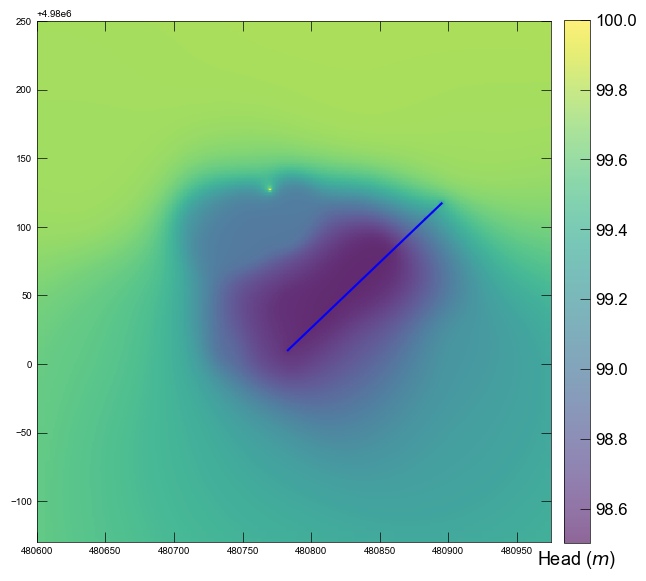

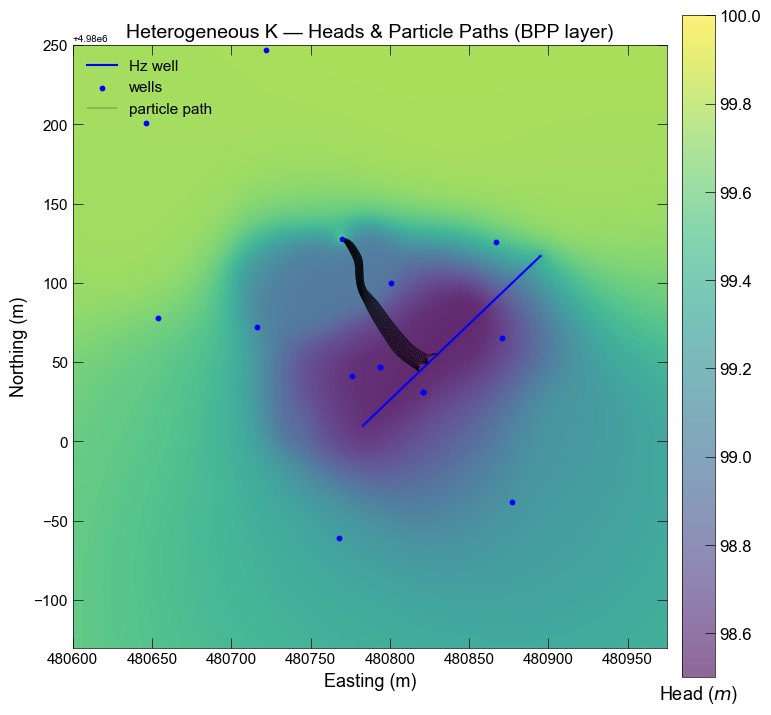

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing solution package ems...
  writing package tracer_sim-gwf.gwfprt...
  writing model tracer_sim-gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package oc...
    writing package ic...
    writing package chd_0...
  writing model tracer_sim-prt...
    writing model name file...
    writing package mip...
    writing package dis...
    writing package prp1...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.2 05/12/2025

   MODFLOW 6 compiled May 24 2025 11:42:11 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running 

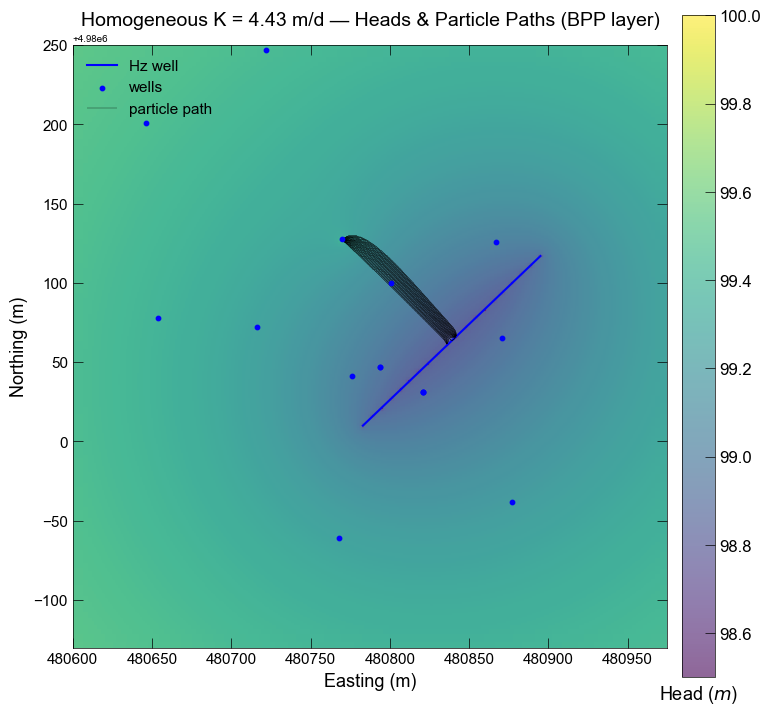

In [31]:
from matplotlib.patches import Patch
import shutil

# --- load well locations ---
df = pd.read_csv("../data/wells_data.csv", index_col=0)
wells_site = df.loc[df.index != 'MLAC_center'].to_dict(orient='index')
wells_e = [coords['Easting'] for coords in wells_site.values()]
wells_n = [coords['Northing'] for coords in wells_site.values()]
# --- plot function ---
def plot_heads(ax, gwf, heads, pathlines_filtered, title, vmin=None, vmax=None):
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
    pc = mm.plot_array(heads, alpha=0.6, vmin=vmin, vmax=vmax)
    cb = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.02)
    cb.ax.set_xlabel(r"Head ($m$)", fontsize=13)
    cb.ax.tick_params(labelsize=12)
    ax.set_xlim(480600, 480975)
    ax.set_ylim(4979870, 4980250)
    ax.plot(
        [wells["horizontal_well"]["start_easting"], wells["horizontal_well"]["end_easting"]],
        [wells["horizontal_well"]["start_northing"], wells["horizontal_well"]["end_northing"]],
        color='blue', label="Hz well", linewidth=1.5
    )
    ax.scatter(wells_e, wells_n, marker="o", color="blue", label="wells", s=10, zorder=5)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Easting (m)", fontsize=13)
    ax.set_ylabel("Northing (m)", fontsize=13)
    ax.tick_params(labelsize=11)
    mm.plot_pathline(
        pathlines_filtered, layer="all", colors="black", 
        alpha=0.8, linewidth=0.3, label="particle path"
    )
    ax.legend(fontsize=11, loc="upper left")
    return mm
# ============================================================
# RUN 1: Heterogeneous K
# ============================================================

# set output filenames for hetero run
trackcsvfile_prt_hetero = f"{prt_name}_hetero.trk.csv"
budgetfile_prt_hetero   = f"{prt_name}_hetero.cbb"

oc.trackcsv_filerecord.set_data([trackcsvfile_prt_hetero])
oc.budget_filerecord.set_data([budgetfile_prt_hetero])

sim.write_simulation()
sim.run_simulation(silent=False)

# load immediately after run 1
hf_hetero = flopy.utils.HeadFile(os.path.join(model_ws, f"{gwf_name}.hds"))
head_hetero = hf_hetero.get_data(kstpkper=(0, 1))
hf_hetero.close()

pathlines_hetero = pd.read_csv(os.path.join(model_ws, trackcsvfile_prt_hetero))
pathlines_hetero_filtered = pathlines_hetero[pathlines_hetero['irpt'] % 500 == 0]

print("Hetero head BPP - min:", head_hetero[1].min(), " max:", head_hetero[1].max())
print("Hetero pathlines shape:", pathlines_hetero.shape)

with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    plot_heads(ax, gwf, head_hetero[1, :, :], pathlines_hetero_filtered,
               "Heterogeneous K — Heads & Particle Paths (BPP layer)")
    plt.tight_layout()
    plt.savefig(os.path.join(model_ws, "heads_pathlines_hetero.png"), dpi=150, bbox_inches="tight")
    plt.show()

# ============================================================
# RUN 2: Homogeneous K = 4.43 m/day
# ============================================================

# set output filenames for homo run
trackcsvfile_prt_homo = f"{prt_name}_homo.trk.csv"
budgetfile_prt_homo   = f"{prt_name}_homo.cbb"

oc.trackcsv_filerecord.set_data([trackcsvfile_prt_homo])
oc.budget_filerecord.set_data([budgetfile_prt_homo])

# switch K to homogeneous
K_homogeneous = 4.43
npf = gwf.get_package("npf")
npf.k.set_data(
    [K_homogeneous * np.ones((nrow, ncol)) for _ in range(nlay)]
)

sim.write_simulation()
sim.run_simulation(silent=False)

# load immediately after run 2
hf_homo = flopy.utils.HeadFile(os.path.join(model_ws, f"{gwf_name}.hds"))
head_homo = hf_homo.get_data(kstpkper=(0, 1))
hf_homo.close()

pathlines_homo = pd.read_csv(os.path.join(model_ws, trackcsvfile_prt_homo))
pathlines_homo_filtered = pathlines_homo[pathlines_homo['irpt'] % 500 == 0]

print("Homo head BPP - min:", head_homo[1].min(), " max:", head_homo[1].max())
print("Homo pathlines shape:", pathlines_homo.shape)
print("Heads identical?", np.allclose(head_hetero[1], head_homo[1]))

with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect("equal")
    plot_heads(ax, gwf, head_homo[1, :, :], pathlines_homo_filtered,
               "Homogeneous K = 4.43 m/d — Heads & Particle Paths (BPP layer)")
    plt.tight_layout()
    plt.savefig(os.path.join(model_ws, "heads_pathlines_homo.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [56]:
head.min()

np.float64(98.5)

In [57]:
pathlines

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,2,1,1,2,199996,0,1,0,14.0,14.000000,6803.518460,6888.518460,-4.572000,NaN
1,2,1,2,1,1,2,210474,0,1,5,14.0,14.068136,6806.323122,6862.492730,-4.575169,NaN
2,2,1,2,1,1,3,368007,0,1,5,14.0,14.188377,6811.018517,6843.873502,-5.774505,NaN
3,2,1,2,1,1,3,369561,0,1,5,14.0,14.308617,6812.655086,6839.841546,-6.828700,NaN
4,2,1,2,1,1,3,371503,0,1,5,14.0,14.428858,6815.105542,6834.920028,-7.012359,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125185,2,1,2,1,10000,3,374247,0,1,5,14.0,15.150301,6843.200457,6828.221226,-6.154847,NaN
125186,2,1,2,1,10000,3,374637,0,1,5,14.0,15.270541,6844.675886,6826.564891,-5.638520,NaN
125187,2,1,2,1,10000,3,375414,0,1,5,14.0,15.390782,6845.941049,6825.196999,-5.076544,NaN
125188,2,1,2,1,10000,2,227206,0,1,5,14.0,15.511022,6854.004552,6818.731326,-4.643755,NaN


In [58]:
termination_pts = pathlines[pathlines.ireason == 3].set_index('irpt')

In [59]:
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
irpt,,,,,,,,,,,,,,,
1,2,1,2,1,2,234570,0,5,3,14.0,15.055093,6845.885796,6800.513460,-4.557241,NaN
2,2,1,2,1,2,234570,0,5,3,14.0,15.055513,6845.890328,6800.513460,-4.557409,NaN
3,2,1,2,1,2,234570,0,5,3,14.0,15.055588,6845.894825,6800.513460,-4.557384,NaN
4,2,1,2,1,2,234570,0,5,3,14.0,15.055748,6845.899381,6800.513460,-4.557055,NaN
5,2,1,2,1,2,234570,0,5,3,14.0,15.055557,6845.903912,6800.513460,-4.556527,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,2,1,2,1,2,227992,0,5,3,14.0,15.571059,6863.513460,6817.300066,-4.521238,NaN
9997,2,1,2,1,2,227992,0,5,3,14.0,15.568347,6863.513460,6817.289925,-4.518957,NaN
9998,2,1,2,1,2,227992,0,5,3,14.0,15.565603,6863.513460,6817.280323,-4.517013,NaN


In [60]:
termination_pts['elapsed_time'] = termination_pts.t - termination_pts.trelease
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name,elapsed_time
irpt,,,,,,,,,,,,,,,,
1,2,1,2,1,2,234570,0,5,3,14.0,15.055093,6845.885796,6800.513460,-4.557241,NaN,1.055093
2,2,1,2,1,2,234570,0,5,3,14.0,15.055513,6845.890328,6800.513460,-4.557409,NaN,1.055513
3,2,1,2,1,2,234570,0,5,3,14.0,15.055588,6845.894825,6800.513460,-4.557384,NaN,1.055588
4,2,1,2,1,2,234570,0,5,3,14.0,15.055748,6845.899381,6800.513460,-4.557055,NaN,1.055748
5,2,1,2,1,2,234570,0,5,3,14.0,15.055557,6845.903912,6800.513460,-4.556527,NaN,1.055557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,2,1,2,1,2,227992,0,5,3,14.0,15.571059,6863.513460,6817.300066,-4.521238,NaN,1.571059
9997,2,1,2,1,2,227992,0,5,3,14.0,15.568347,6863.513460,6817.289925,-4.518957,NaN,1.568347
9998,2,1,2,1,2,227992,0,5,3,14.0,15.565603,6863.513460,6817.280323,-4.517013,NaN,1.565603


In [61]:
termination_pts.elapsed_time.describe()

count    10000.000000
mean         1.268618
std          0.236854
min          1.042184
25%          1.084221
50%          1.164374
75%          1.412570
max          2.530781
Name: elapsed_time, dtype: float64

<Axes: ylabel='Density'>

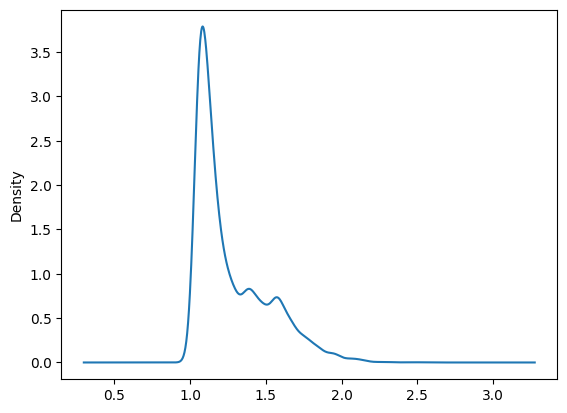

In [62]:
termination_pts.elapsed_time.plot(kind='kde')
#plt.xscale("log")
#plt.yscale("log")

BTC

In [63]:
n_bins = 200
time_bins = np.linspace(0, settings['tracking_days'], n_bins)
arrivals, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins)
mass = (arrivals / len(termination_pts)) * 2024 #2024 mg

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

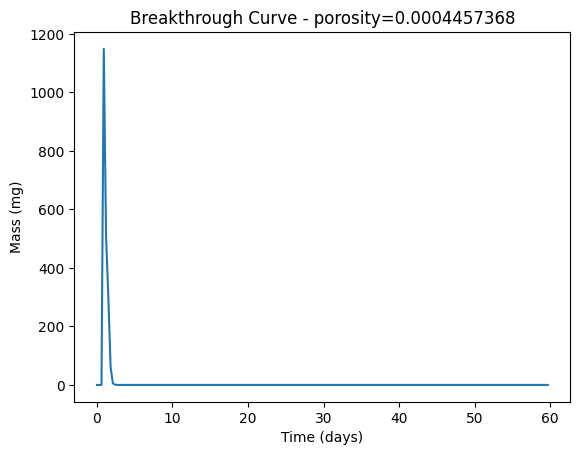

In [64]:
plt.plot(time_bins[:-1], mass)
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Mass (mg)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

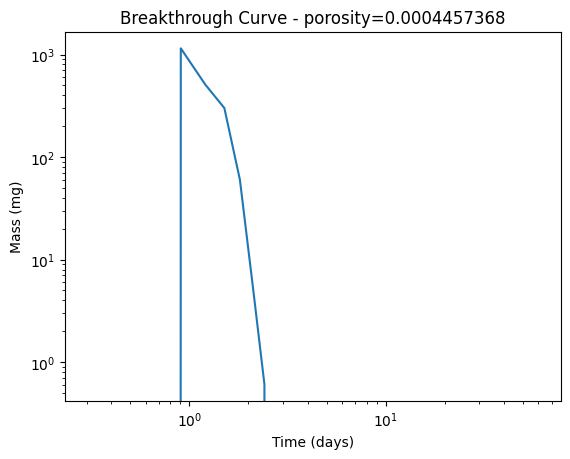

In [65]:
plt.plot(time_bins[:-1], mass)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Mass (mg)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

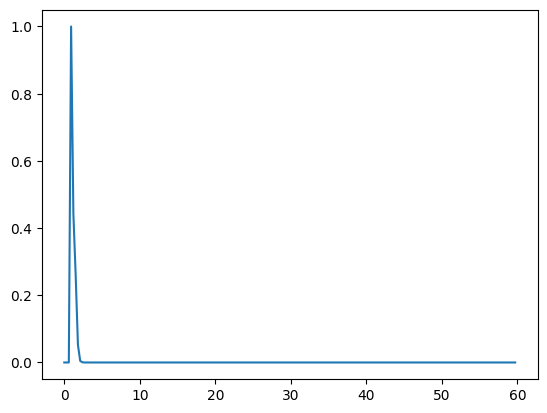

In [66]:
plt.plot(time_bins[:-1], mass/np.max(mass))

In [67]:
termination_pts['velocity_m_per_day'] = 92/termination_pts['elapsed_time']
termination_pts['Q_m3_day'] = termination_pts['velocity_m_per_day'] * porosity * 0.61  

In [68]:
termination_pts

,kper,kstp,imdl,iprp,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name,elapsed_time,velocity_m_per_day,Q_m3_day
irpt,,,,,,,,,,,,,,,,,,
1,2,1,2,1,2,234570,0,5,3,14.0,15.055093,6845.885796,6800.513460,-4.557241,NaN,1.055093,87.196110,0.023709
2,2,1,2,1,2,234570,0,5,3,14.0,15.055513,6845.890328,6800.513460,-4.557409,NaN,1.055513,87.161385,0.023699
3,2,1,2,1,2,234570,0,5,3,14.0,15.055588,6845.894825,6800.513460,-4.557384,NaN,1.055588,87.155251,0.023697
4,2,1,2,1,2,234570,0,5,3,14.0,15.055748,6845.899381,6800.513460,-4.557055,NaN,1.055748,87.142018,0.023694
5,2,1,2,1,2,234570,0,5,3,14.0,15.055557,6845.903912,6800.513460,-4.556527,NaN,1.055557,87.157763,0.023698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,2,1,2,1,2,227992,0,5,3,14.0,15.571059,6863.513460,6817.300066,-4.521238,NaN,1.571059,58.559240,0.015922
9997,2,1,2,1,2,227992,0,5,3,14.0,15.568347,6863.513460,6817.289925,-4.518957,NaN,1.568347,58.660480,0.015950
9998,2,1,2,1,2,227992,0,5,3,14.0,15.565603,6863.513460,6817.280323,-4.517013,NaN,1.565603,58.763301,0.015978


In [69]:
bin_width = settings['tracking_days']/n_bins

In [70]:
mean_flow_per_bin, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins, weights=termination_pts['Q_m3_day'])
count_per_bin, _ = np.histogram(termination_pts['elapsed_time'], bins=time_bins)
mean_flow = mean_flow_per_bin / count_per_bin

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

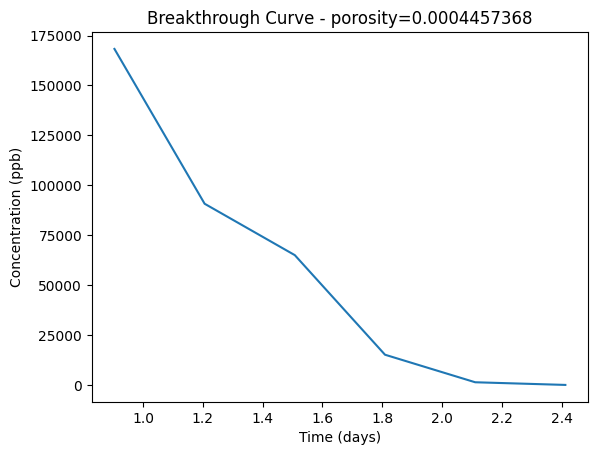

In [71]:

conc_ppb = (mass * 1.e+3) / (mean_flow * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb)
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Text(0.5, 1.0, 'Breakthrough Curve - porosity=0.0004457368')

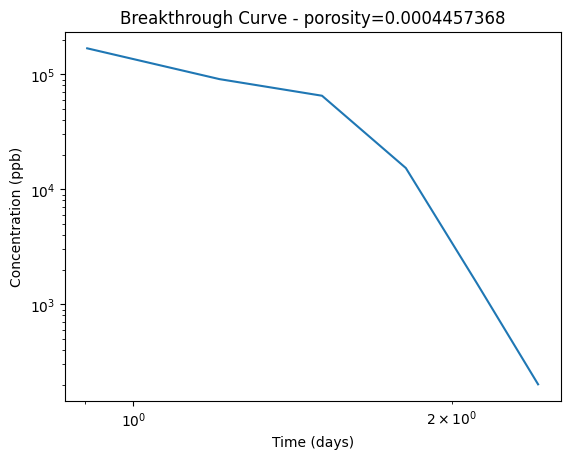

In [72]:
conc_ppb = (mass * 1.e+3) / (mean_flow * bin_width * 1.e+3)
plt.plot(time_bins[:-1], conc_ppb)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Concentration (ppb)")
plt.title(f"Breakthrough Curve - porosity={porosity}")

Comparing field and simulated BTCs

In [73]:
data_22 = pd.read_csv('../data/field_BTCs/results_MLAC2022.csv')
data_23 = pd.read_csv('../data/field_BTCs/results_MLAC2023.csv')
data_24 = pd.read_csv('../data/field_BTCs/2024_BTC.csv')

In [74]:
data_22.loc[data_22['cnc_uranine'] == data_22['cnc_uranine'].max(), 'time']
#data_22.head()

28    14.0
Name: time, dtype: float64

In [75]:
data_22.head()

,Unnamed: 0,sample,date,time,n_iter,df,cnc_uranine,area1,area2,area3,area4
0,0,MLAC.HZ.220914.1000_CorrectionData.txt,2022-09-14 10:00:00,0.0,15,1,0.005336,210.954300,295.952108,133.704141,0.000000
1,1,MLAC.HZ.220914.1030_CorrectionData.txt,2022-09-14 10:30:00,0.5,15,1,0.004026,159.144969,268.292107,172.064782,154.286696
2,2,MLAC.HZ.220914.1100_CorrectionData.txt,2022-09-14 11:00:00,1.0,15,1,0.006233,246.379313,270.153421,162.704738,202.706425
3,3,MLAC.HZ.220914.1130_CorrectionData.txt,2022-09-14 11:30:00,1.5,15,1,0.004199,166.004081,291.043041,164.298635,217.947872
4,4,MLAC.HZ.220914.1200_CorrectionData.txt,2022-09-14 12:00:00,2.0,15,1,0.004038,159.608131,313.690192,202.346581,246.005446


In [76]:
conc_ppb

array([            nan,             nan,             nan, 168296.76111009,
        90838.18635272,  65128.18090333,  15314.23021837,   1534.14663072,
          201.41863556,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,             nan,             nan,             nan,
                   nan,  

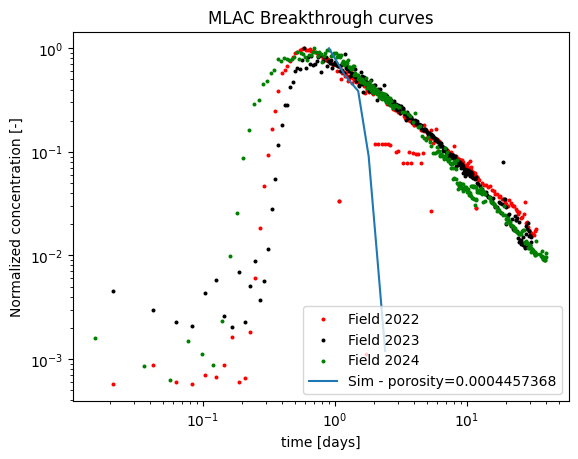

In [77]:
plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)

plt.plot(time_bins[:-1], conc_ppb/np.nanmax(conc_ppb), label=f'Sim - porosity={porosity}')

plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title('MLAC Breakthrough curves')
plt.xscale('log')
plt.yscale('log')
plt.legend()
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()

In [78]:
k_files_path

'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK'

In [79]:
df_to_save = pd.DataFrame({'time': time_bins[:-1], 'normalized_conc': conc_ppb/np.nanmax(conc_ppb)})
#time_bins[:-1], conc_ppb/np.nanmax(conc_ppb)
df_to_save.head()

,time,normalized_conc
0,0.000000,NaN
1,0.301508,NaN
2,0.603015,NaN
3,0.904523,1.00000
4,1.206030,0.53975


In [80]:
df_to_save.to_csv('prior_sim_BTC.csv')

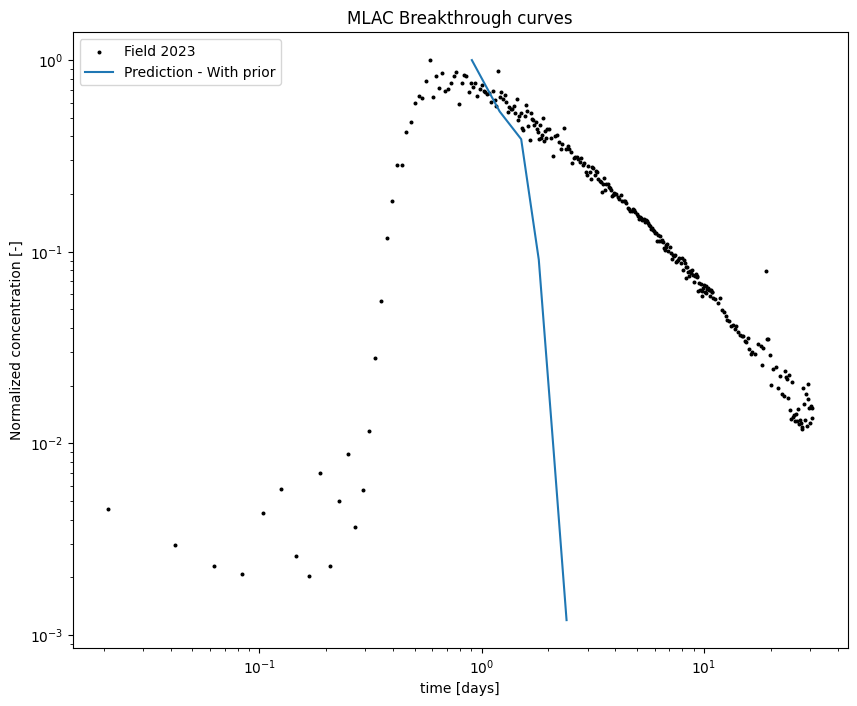

In [91]:
plt.figure(figsize=(10, 8))
#plt.scatter(data_22['time']/24, data_22['cnc_uranine']/data_22['cnc_uranine'].max(), label='Field 2022', color='red', s=3.5)
plt.scatter(data_23['time']/24, data_23['cnc_uranine']/data_23['cnc_uranine'].max(), label='Field 2023', color='k',  s=3.5)
#plt.scatter(data_24['time (day)'], data_24[' concentration (ppb) ']/data_24[' concentration (ppb) '].max(), label='Field 2024', color='green', s=3.5)
#plt.plot(x, y, linestyle='--', color='k', linewidth=1.5)
#plt.plot(x2, y2, linestyle='--', color='red', linewidth=1.5)
#plt.plot(x3, y3, linestyle='--', color='green', linewidth=1.5)
no_prior = pd.read_csv('no_prior_sim_BTC.csv')
prior = pd.read_csv('prior_sim_BTC.csv')

#plt.plot(no_prior['time'], no_prior['normalized_conc'], label=f'Prediction - No prior')

plt.plot(prior['time'], prior['normalized_conc'], label=f'Prediction - With prior')


#plt.plot(time_bins[:-1], conc_ppb/np.nanmax(conc_ppb), label=f'Sim - porosity={porosity}')

plt.xlabel('time [days]')
plt.ylabel('Normalized concentration [-]')
plt.title('MLAC Breakthrough curves')
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper left')
#plt.text(1.8, 0.11, '1.10', color='red')
#plt.text(7.7, 0.44, '1.29', color='k')
#plt.text(0.49, 0.44, '1.27', color='green')
#plt.ylim(0.015, 1.6)
#plt.xlim(0.1, 40)
plt.show()

In [82]:
try:
    import pyvista as pv
    from flopy.export.vtk import Vtk

    vert_exag = 10

    #vtk = Vtk(
        #model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False
    #)
    #vtk.add_model(gwf)
    #vtk.add_pathline_points(mp7_pathlines.to_records(index=False))
    #gwf_mesh, mp7_mesh = vtk.to_pyvista()

    # this is a little awkward due to the design of `Vtk`, which can only
    # have one set of pathlines at a time.
    vtk = Vtk(
        model=gwf, binary=False, vertical_exageration=vert_exag, smooth=False
    )
    vtk.add_model(gwf)
    vtk.add_pathline_points(pathlines.to_records(index=False))
    gwf_mesh, prt_mesh = vtk.to_pyvista()

    def get_nn(k, i, j):
        """Convert a structured grid cell index to a node number."""
        return k * nrow * ncol + i * ncol + j

    # add meshes
    riv_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[1] - delc,
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            botm[0] * vert_exag,
            head[(0, 0, ncol - 1)] * vert_exag,
        ]
    )
    #well_cellid = get_nn(0, *wel_loc[1:])
    #well_points = gwf.modelgrid.verts[gwf.modelgrid.iverts[well_cellid]]
    #well_xs, well_ys = list(zip(*well_points))
    '''wel_mesh = pv.Box(
        bounds=[
            min(well_xs),
            max(well_xs),
            min(well_ys),
            max(well_ys),
            botm[-1] * vert_exag,
            botm[-2] * vert_exag,
        ]
    )'''
    bed_mesh = pv.Box(
        bounds=[
            gwf.modelgrid.extent[0],
            gwf.modelgrid.extent[1],
            gwf.modelgrid.extent[2],
            gwf.modelgrid.extent[3],
            botm[1] * vert_exag,
            botm[0] * vert_exag,
        ]
    )

    # create the plot
    axes = pv.Axes(show_actor=False, actor_scale=2.0, line_width=5)
    pv.set_jupyter_backend("static")
    # pv.set_jupyter_backend("trame")
    p = pv.Plotter(
        window_size=[500, 500],
        notebook=True,
    )
    p.enable_anti_aliasing()
    p.add_mesh(gwf_mesh, opacity=0.025, style="wireframe")
    '''p.add_mesh(
        mp7_mesh,
        point_size=5,
        line_width=2.5,
        smooth_shading=True,
        color="white",
    )'''
    p.add_mesh(
        prt_mesh,
        point_size=5,
        line_width=2.5,
        smooth_shading=True,
        color="gray",
    )
    p.add_mesh(riv_mesh, color="teal", opacity=0.2)
    #p.add_mesh(wel_mesh, color="red", opacity=0.3)
    p.add_mesh(bed_mesh, color="tan", opacity=0.1)
    p.show()
except:
    print("PyVista not found.")

PyVista not found.


In [83]:
#k_files_path = "C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp3_no_ss_no_prior"


In [84]:
k_files_path

'C:/Users/lima0055/Documents/MLAC-3D-HT/src/pyemu/PMW-6-constantK/master_pp_newweights_newinitialK'

In [85]:
hk1 = np.loadtxt(os.path.join(k_files_path, "k_layer1.txt"))
hk2 = np.loadtxt(os.path.join(k_files_path, "k_layer2.txt"))
hk3 = np.loadtxt(os.path.join(k_files_path, "k_layer3.txt"))

In [86]:
np.max(hk2)

np.float64(654.1793)

In [87]:
from scipy.stats import gmean

In [88]:
10**(np.mean(np.log10(hk3)))

np.float64(0.5782260732472413)

In [89]:
np.std(hk3)

np.float64(4.119113214929194)

In [90]:
((0.0092 * 12 * 1.e-3) / (9.8 * 998))**(1/2)

0.00010624444402518855